In [88]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [89]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")
target = "SalePrice"

cat_cols = (
    train_df.drop(columns=[target])
    .select_dtypes(include=["object", "string"])
    .columns.tolist()
)
num_cols = (
    train_df.drop(columns=[target])
    .select_dtypes(exclude=["object", "string"])
    .columns.tolist()
)

In [90]:
bins = [-float("inf"), 100000, 350000, float("inf")]
labels = [0, 1, 2]
train_df[target] = pd.cut(train_df[target], bins=bins, labels=labels).astype(int)

In [91]:
train_encoded = pd.get_dummies(train_df[cat_cols], prefix=cat_cols)
test_encoded = pd.get_dummies(test_df[cat_cols], prefix=cat_cols)

test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

train_df = pd.concat([train_df[num_cols], train_encoded, train_df[target]], axis=1)
test_df = pd.concat([test_df[num_cols], test_encoded], axis=1)

cat_cols = train_encoded.columns.tolist()

In [92]:
scaler = StandardScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

In [93]:
train_df.head()

,YearBuilt,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),N_manager,N_elevators,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),...,TimeToSubway_no_bus_stop_nearby,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice
0,0.344797,-0.379605,-1.186567,-0.379655,-0.952778,-1.027793,-1.432820,-0.351614,-1.120745,-0.423026,...,False,False,False,False,False,True,False,False,False,1
1,-2.051157,-0.969979,-0.526972,-0.523554,-1.217399,-1.337950,-1.173621,-1.204839,0.621197,-1.552482,...,False,False,False,False,True,False,False,False,False,0
2,-2.051157,-0.969979,-0.790810,-0.523554,-1.217399,-1.337950,-1.173621,-1.204839,0.621197,-1.552482,...,False,False,False,False,True,False,False,False,False,0
3,0.344797,2.850549,-0.526972,0.260925,-0.090309,-0.407477,-0.007228,-0.351614,-1.991717,-0.874808,...,False,False,False,False,False,False,False,True,False,2
4,-1.252506,-0.821735,-1.318486,-0.235757,-1.210049,-0.717635,-0.396026,-1.204839,-0.249774,0.706431,...,False,False,False,False,False,False,True,False,False,0


In [94]:
class MultiClassClassifier(nn.Module):
    def __init__(self, input, output):
        super(MultiClassClassifier, self).__init__()

        self.fully_connected1 = nn.Linear(input, 100)
        self.batch_norm1 = nn.BatchNorm1d(100)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.5)
        self.fully_connected2 = nn.Linear(100, 300)
        self.batch_norm2 = nn.BatchNorm1d(300)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.5)
        self.fully_connected3 = nn.Linear(300, 100)
        self.batch_norm3 = nn.BatchNorm1d(100)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(p=0.5)
        self.fully_connected4 = nn.Linear(100, output)

    def forward(self, X_categorical, X_non_categorical):
        x = torch.cat([X_categorical, X_non_categorical], dim=1)

        x = self.fully_connected1(x)
        x = self.batch_norm1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fully_connected2(x)
        x = self.batch_norm2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fully_connected3(x)
        x = self.batch_norm3(x)
        x = self.relu3(x)
        x = self.dropout3(x)

        x = self.fully_connected4(x)
        return x


In [105]:
X_cat = torch.tensor(train_df[cat_cols].values, dtype=torch.float32)
X_num = torch.tensor(train_df[num_cols].values, dtype=torch.float32)
y = torch.tensor(train_df[target].values, dtype=torch.int64)

X_cat_test = torch.tensor(test_df[cat_cols].values, dtype=torch.float32)
X_num_test = torch.tensor(test_df[num_cols].values, dtype=torch.float32)

X_cat_train, X_cat_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_cat, X_num, y, test_size=0.15, random_state=42
)

train_dataset = TensorDataset(X_cat_train, X_num_train, y_train)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [106]:
def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct = (pred_targets == targets)[targets == i].sum()
        accuracies.append(class_correct / (targets == i).sum())
    return np.mean(accuracies)

def evaluate(model, X_cat_val, X_num_val, y_val):
    with torch.no_grad():
        outputs = model(X_cat_val, X_num_val)
        _, predicted = torch.max(outputs, 1)
        accuracy = calc_accuracy(predicted.numpy(), y_val.numpy())
    return accuracy

In [107]:
input_size = len(cat_cols) + len(num_cols)
output_size = len(train_df[target].unique())

class_weights = 1 / train_df[target].value_counts().sort_index()
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)


model = MultiClassClassifier(input_size, output_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

model.train()

losses = []
val_acc = []
train_acc = []

for epoch in range(50):
    epoch_loss = 0.0
    for cat_b, num_b, y_b in train_loader:
        optimizer.zero_grad()
        outputs = model(cat_b, num_b)
        loss = criterion(outputs, y_b)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    losses.append(avg_loss)

    if (epoch + 1) % 1 == 0:
        model.eval()
        val_accuracy = evaluate(model, X_cat_val, X_num_val, y_val)
        train_accuracy = evaluate(model, X_cat_train, X_num_train, y_train)
        print(f"Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Accuracy: {val_accuracy:.4f}")
        val_acc.append(val_accuracy)
        train_acc.append(train_accuracy)

        model.train()

Epoch 1, Loss: 0.7473
Training Accuracy: 0.7973
Validation Accuracy: 0.7851
Epoch 2, Loss: 0.5219
Training Accuracy: 0.8471
Validation Accuracy: 0.8365
Epoch 3, Loss: 0.4738
Training Accuracy: 0.8693
Validation Accuracy: 0.8704
Epoch 4, Loss: 0.4361
Training Accuracy: 0.8742
Validation Accuracy: 0.8750
Epoch 5, Loss: 0.4203
Training Accuracy: 0.8759
Validation Accuracy: 0.8688
Epoch 6, Loss: 0.4058
Training Accuracy: 0.8710
Validation Accuracy: 0.8568
Epoch 7, Loss: 0.3927
Training Accuracy: 0.8895
Validation Accuracy: 0.8795
Epoch 8, Loss: 0.3720
Training Accuracy: 0.8875
Validation Accuracy: 0.8719
Epoch 9, Loss: 0.3639
Training Accuracy: 0.8886
Validation Accuracy: 0.8772
Epoch 10, Loss: 0.3698
Training Accuracy: 0.8864
Validation Accuracy: 0.8726
Epoch 11, Loss: 0.3544
Training Accuracy: 0.8879
Validation Accuracy: 0.8795
Epoch 12, Loss: 0.3599
Training Accuracy: 0.8886
Validation Accuracy: 0.8817
Epoch 13, Loss: 0.3596
Training Accuracy: 0.8901
Validation Accuracy: 0.8659
Epoch 14

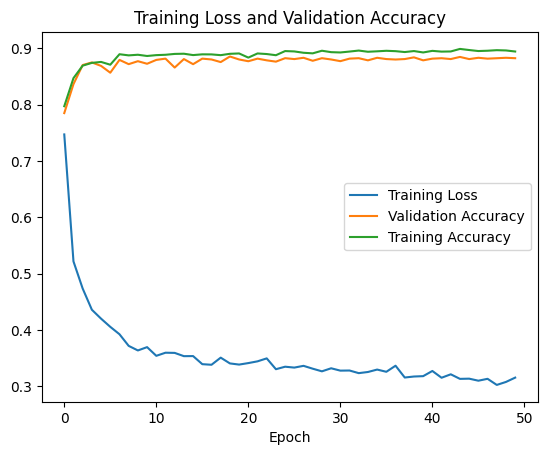

In [108]:
import matplotlib.pyplot as plt

plt.plot(losses, label="Training Loss")
plt.plot(val_acc, label="Validation Accuracy")
plt.plot(train_acc, label="Training Accuracy")
plt.xlabel("Epoch")
plt.title("Training Loss and Validation Accuracy")
plt.legend()
plt.show()

In [109]:
model.eval()
test_outputs = model(X_cat_test, X_num_test)
_, test_predicted = torch.max(test_outputs, 1)

np.savetxt("output.csv", test_predicted.numpy(), delimiter=",", fmt="%d")